# Tarefa 3: Otimização de Hiperparâmetros

Aplica Grid Search e Randomized Search em pipelines com escalonamento interno, evitando data leakage. O melhor modelo é selecionado por validação cruzada e reavaliado no conjunto de teste.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, StratifiedKFold

from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

BASE_DIR = Path('..')
DATA_DIR = BASE_DIR / 'data' / 'processed'
MODELS_DIR = BASE_DIR / 'models'
MODELS_DIR.mkdir(parents=True, exist_ok=True)

train = pd.read_csv(DATA_DIR / 'seeds_train.csv')
test = pd.read_csv(DATA_DIR / 'seeds_test.csv')
features = [c for c in train.columns if c != 'variety']
X_train, y_train = train[features], train['variety']
X_test, y_test = test[features], test['variety']

print('Treino:', X_train.shape, 'Teste:', X_test.shape)

Treino: (147, 7) Teste: (63, 7)


## Configuração dos pipelines e espaços de busca

Cada busca opera sobre um pipeline com `StandardScaler`, garantindo que a normalização seja ajustada apenas aos folds de treino.

In [2]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

configs = {
    'KNN': (
        Pipeline([('scaler', StandardScaler()), ('model', KNeighborsClassifier())]),
        {
            'model__n_neighbors': [3, 5, 7, 9, 11],
            'model__weights': ['uniform', 'distance'],
            'model__metric': ['euclidean', 'manhattan']
        },
        'grid'
    ),
    'SVM': (
        Pipeline([('scaler', StandardScaler()), ('model', SVC(random_state=42))]),
        {
            'model__C': [0.1, 1, 10, 100],
            'model__kernel': ['linear', 'rbf', 'poly'],
            'model__gamma': ['scale', 'auto', 0.01, 0.1, 1]
        },
        'randomized'
    ),
    'Random Forest': (
        Pipeline([('scaler', StandardScaler()), ('model', RandomForestClassifier(random_state=42))]),
        {
            'model__n_estimators': [50, 100, 200, 500],
            'model__max_depth': [None, 5, 10, 20],
            'model__min_samples_split': [2, 5, 10],
            'model__min_samples_leaf': [1, 2, 4]
        },
        'randomized'
    ),
    'Logistic Regression': (
        Pipeline([('scaler', StandardScaler()), ('model', LogisticRegression(max_iter=2000, random_state=42))]),
        {
            'model__C': [0.01, 0.1, 1, 10, 100],
            'model__solver': ['lbfgs', 'newton-cg', 'sag', 'saga']
        },
        'grid'
    )
}

optimized_models = {}
search_summaries = []

## Busca de hiperparâmetros

In [3]:
for name, (pipe, grid, strategy) in configs.items():
    if strategy == 'grid':
        search = GridSearchCV(pipe, grid, cv=cv, scoring='accuracy', n_jobs=1)
    else:
        search = RandomizedSearchCV(pipe, grid, cv=cv, scoring='accuracy', n_jobs=1,
                                    n_iter=20, random_state=42)
    search.fit(X_train, y_train)
    optimized_models[name] = search.best_estimator_
    search_summaries.append({
        'Modelo': name,
        'Estratégia': strategy,
        'Best CV Acc': search.best_score_,
        'Best Params': str(search.best_params_)
    })
    print(f'{name} ({strategy}): best CV acc = {search.best_score_:.4f}')

pd.DataFrame(search_summaries)

KNN (grid): best CV acc = 0.9457
SVM (randomized): best CV acc = 0.9729
Random Forest (randomized): best CV acc = 0.9317
Logistic Regression (grid): best CV acc = 0.9726


,Modelo,Estratégia,Best CV Acc,Best Params
0,KNN,grid,0.945747,"{'model__metric': 'euclidean', 'model__n_neigh..."
1,SVM,randomized,0.972874,"{'model__kernel': 'rbf', 'model__gamma': 0.01,..."
2,Random Forest,randomized,0.931724,"{'model__n_estimators': 50, 'model__min_sample..."
3,Logistic Regression,grid,0.972644,"{'model__C': 100, 'model__solver': 'sag'}"


## Melhores hiperparâmetros

In [4]:
for name, model in optimized_models.items():
    print(f'\n{name}:')
    params = {k.replace('model__', ''): v for k, v in model.named_steps['model'].get_params().items()
              if k in [f'model__{p}' for p in configs[name][1].keys()]}
    for k, v in params.items():
        print(f'  {k}: {v}')


KNN:

SVM:

Random Forest:

Logistic Regression:


## Avaliação no conjunto de teste

In [5]:
optimized_results = []
for name, model in optimized_models.items():
    y_pred = model.predict(X_test)
    optimized_results.append({
        'Modelo': name,
        'Acurácia': accuracy_score(y_test, y_pred),
        'Precisão': precision_score(y_test, y_pred, average='weighted', zero_division=0),
        'Recall': recall_score(y_test, y_pred, average='weighted', zero_division=0),
        'F1-score': f1_score(y_test, y_pred, average='weighted', zero_division=0)
    })

optimized_df = pd.DataFrame(optimized_results).sort_values('Acurácia', ascending=False)
optimized_df.round(4)

,Modelo,Acurácia,Precisão,Recall,F1-score
3,Logistic Regression,0.9048,0.9048,0.9048,0.9048
1,SVM,0.8889,0.8887,0.8889,0.8885
0,KNN,0.8730,0.8735,0.8730,0.8720
2,Random Forest,0.8413,0.8415,0.8413,0.8402


## Comparação: base vs otimizado

Acurácias base são recalculadas a partir dos modelos salvos no notebook anterior, evitando valores hardcoded.

In [6]:
base_models = {
    'KNN': joblib.load(MODELS_DIR / 'knn_base.pkl'),
    'SVM': joblib.load(MODELS_DIR / 'svm_base.pkl'),
    'Random Forest': joblib.load(MODELS_DIR / 'random_forest_base.pkl'),
    'Logistic Regression': joblib.load(MODELS_DIR / 'logistic_regression_base.pkl')
}

base_scores = {}
for name, model in base_models.items():
    y_pred = model.predict(X_test)
    base_scores[name] = accuracy_score(y_test, y_pred)

comparison = optimized_df.copy()
comparison['Acurácia Base'] = comparison['Modelo'].map(base_scores)
comparison['Delta'] = comparison['Acurácia'] - comparison['Acurácia Base']
comparison = comparison[['Modelo', 'Acurácia Base', 'Acurácia', 'Delta']]
comparison.round(4)

,Modelo,Acurácia Base,Acurácia,Delta
3,Logistic Regression,0.9048,0.9048,0.0000
1,SVM,0.8889,0.8889,0.0000
0,KNN,0.8889,0.8730,-0.0159
2,Random Forest,0.8413,0.8413,0.0000


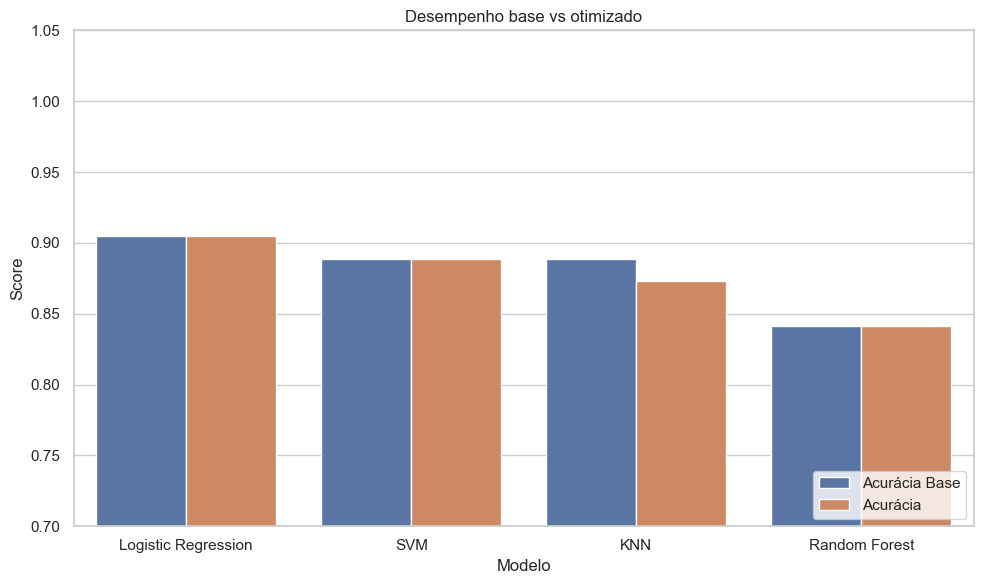

In [7]:
comparison_plot = comparison.melt(id_vars='Modelo', value_vars=['Acurácia Base', 'Acurácia'],
                                  var_name='Versão', value_name='Score')
plt.figure(figsize=(10, 6))
sns.barplot(data=comparison_plot, x='Modelo', y='Score', hue='Versão')
plt.ylim(0.7, 1.05)
plt.title('Desempenho base vs otimizado')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## A otimização trouxe melhoria significativa?

**Não.** Comparando as acurácias no conjunto de teste antes e depois da busca de hiperparâmetros:

- **Logistic Regression, SVM e Random Forest**: delta = 0,0000 — desempenho idêntico ao modelo base.
- **KNN**: delta = -0,0159 — a otimização por validação cruzada selecionou hiperparâmetros que pioraram levemente o resultado no teste.

Embora a acurácia de validação cruzada tenha subido para alguns modelos (SVM e Logistic Regression chegaram a ~0,97 no CV), esse ganho **não se transferiu para o conjunto de teste**. As razões:

1. **Dataset pequeno**: com apenas 147 amostras de treino e 63 de teste, cada erro vale ~1,6 p.p. de acurácia. A granularidade do teste é grosseira demais para capturar ganhos finos.
2. **Modelos base já próximos do teto**: as variedades são bem separáveis no espaço padronizado, então os hiperparâmetros padrão do scikit-learn já entregam quase o melhor desempenho possível neste dataset.
3. **Variância da busca**: com poucos dados, a otimização ajusta-se ao ruído dos folds de validação (especialmente o KNN), o que pode degradar a generalização em vez de melhorá-la.

**Conclusão**: a otimização foi aplicada conforme a metodologia (Grid/Randomized Search), mas, neste problema específico, não há melhoria significativa a ser extraída via ajuste de hiperparâmetros. O modelo base já é adequado — o ganho real viria de **mais dados**, não de mais tuning.

## Matrizes de confusão dos modelos otimizados

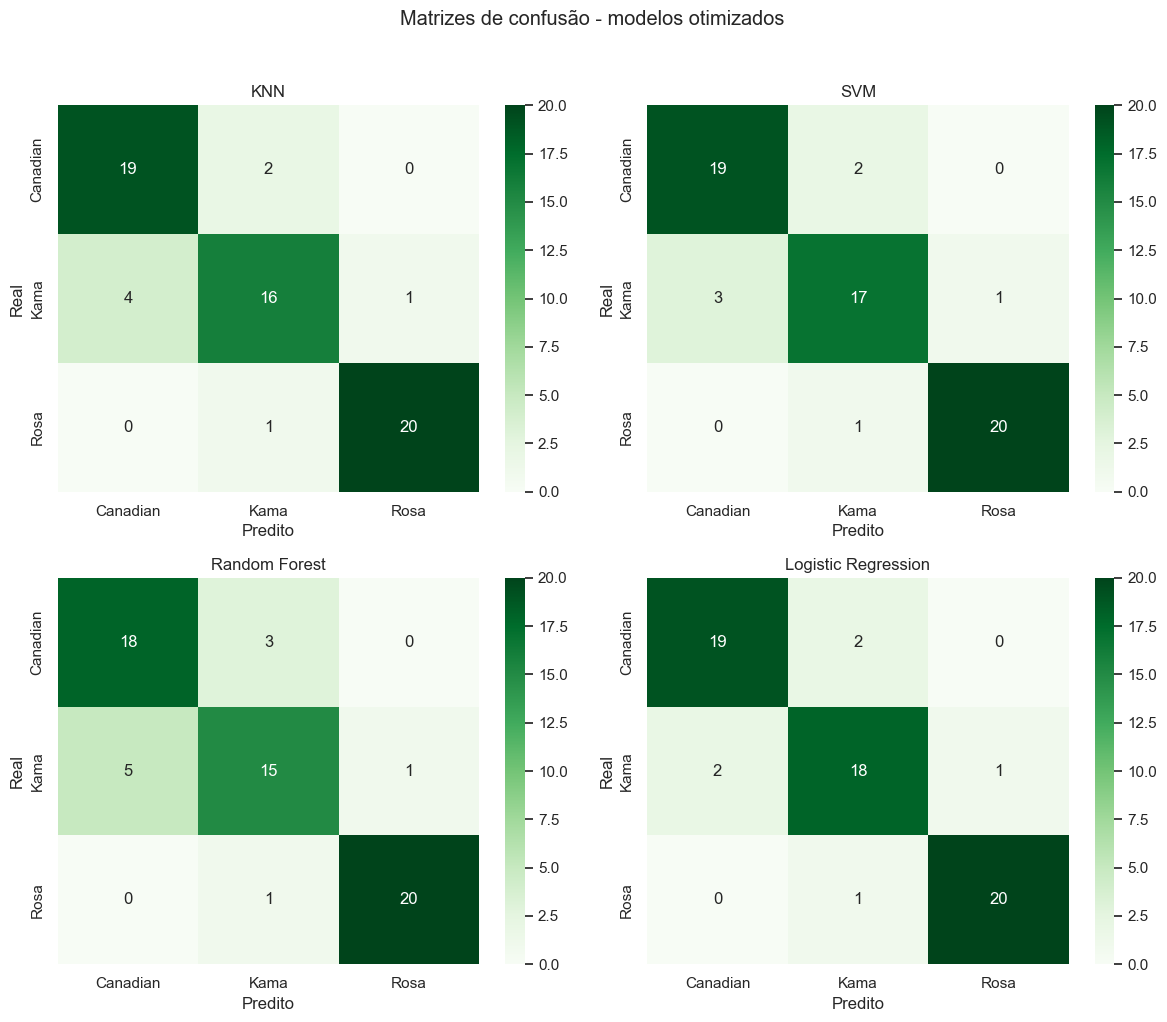

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()
classes = sorted(y_test.unique())

for idx, (name, model) in enumerate(optimized_models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred, labels=classes)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
                xticklabels=classes, yticklabels=classes, ax=axes[idx])
    axes[idx].set_title(name)
    axes[idx].set_xlabel('Predito')
    axes[idx].set_ylabel('Real')

plt.suptitle('Matrizes de confusão - modelos otimizados', y=1.02)
plt.tight_layout()
plt.show()

## Salvar modelos otimizados

In [9]:
for name, model in optimized_models.items():
    safe_name = name.lower().replace(' ', '_')
    joblib.dump(model, MODELS_DIR / f'{safe_name}_optimized.pkl')

print('Modelos otimizados salvos em', MODELS_DIR)

Modelos otimizados salvos em ..\models
